In [3]:
from qick import *
%pylab inline

%pylab is deprecated, use %matplotlib inline and import the required libraries.
Populating the interactive namespace from numpy and matplotlib


In [4]:
import numpy as np
from numpy.polynomial import Polynomial
import matplotlib.ticker as mtick
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

import xarray as xr

In [5]:
import os
import sys
sys.path.insert(0, '../../pattern/')
sys.path.insert(0, '../../instrument/')

In [6]:
from xilinx_qick.class_drx import drx
from xilinx_qick.class_rox import rox
from xilinx_qick.class_sweep import sweep
from xilinx_qick.instr_xilinx_v1 import XilinxProg

In [7]:
xilinx_1 = XilinxProg(ip_address="10.0.100.21", mode='AveragerProgram')
xilinx_1.reps = 1

dr_ch1 = 1
ro_ch1 = 1

freq_ch1 = 500e6

Pyro.NameServer PYRO:Pyro.NameServer@0.0.0.0:8888
rfsoc4x2_1 PYRO:obj_6aec762e7d7e4127ba232b014f3e4391@10.0.100.21:44885
QICK running on RFSoC4x2, software version 0.2.381

Firmware configuration (built Wed Sep  6 18:49:29 2023):

	Global clocks (MHz): tProc dispatcher timing 409.600, RF reference 491.520
	Groups of related clocks: [tProc clock, DAC tile 0], [DAC tile 2], [ADC tile 0]

	2 signal generator channels:
	0:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 65536 complex samples (6.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 0, blk 0 is DAC_B
	1:	axis_signal_gen_v6 - fs=9830.400 Msps, fabric=614.400 MHz
		envelope memory: 65536 complex samples (6.667 us)
		32-bit DDS, range=9830.400 MHz
		DAC tile 2, blk 0 is DAC_A

	2 readout channels:
	0:	axis_readout_v2 - configured by PYNQ
		fs=4423.680 Msps, decimated=552.960 MHz, 32-bit DDS, range=4423.680 MHz
		axis_avg_buffer v1.0 (no edge counter, no weights)
		memory 16384 accumulated, 1024 decima

In [8]:
dr_readout = drx(soc=xilinx_1.soccfg,
                 dr_ch=dr_ch1, ro_ch=ro_ch1,
                 frequency= freq_ch1 / 1e6, gain=1,
                 phase=0, delay=0.2, sleep=1)

s_1 = np.array([0, 1, 2, 1, 0])
ph_1 = (-0.61977477-0.78477974j)

dr_readout.wave.add(name='x2', t_data=[0, 0.25, 0.5, 0.75, 1.0], s_data=s_1/ph_1, idx=-1, interp_order=3)
dr_readout.rox.set(frequency=freq_ch1 / 1e6, length=1, delay=0.2, sleep=1)
xilinx_1.add(dr_readout=dr_readout)

In [9]:
dr_readout.wave.items[0]

waveform(name='x2', length_cyl=9824, i_data=array([ 0.        , -0.00252517, -0.01009933, ..., -0.01009933,
       -0.00252517,  0.        ]), q_data=array([-0.        , -0.00319746, -0.01278811, ..., -0.01278811,
       -0.00319746, -0.        ]))

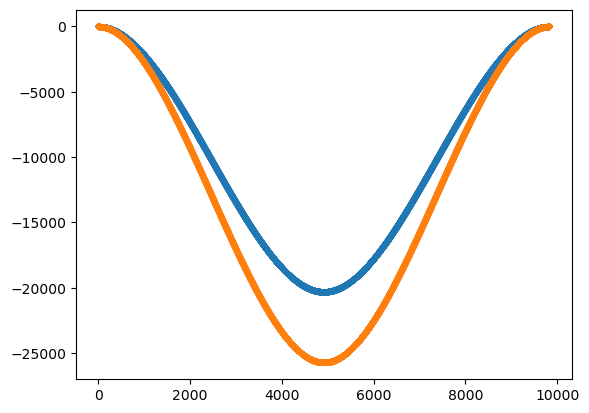

In [10]:
plt.figure()
plt.plot(dr_readout.wave.items[0].i_data, '.-')
plt.plot(dr_readout.wave.items[0].q_data, '.-')
plt.show()

In [11]:
iq_data = xilinx_1.acquire_decimated(load_pulses=True, progress=False)
iq_data.to_zarr('test_1.zarr', mode='w')

C:\Users\qcduser\anaconda3\envs\QCDLabs\Lib\site-packages\zarr\api\asynchronous.py:247: ZarrUserWarning: Consolidated metadata is currently not part in the Zarr format 3 specification. It may not be supported by other zarr implementations and may change in the future.
  warnings.warn(


In [12]:
with xr.open_zarr("test_1.zarr") as f:
    iq_mat = f['IQ decimated']

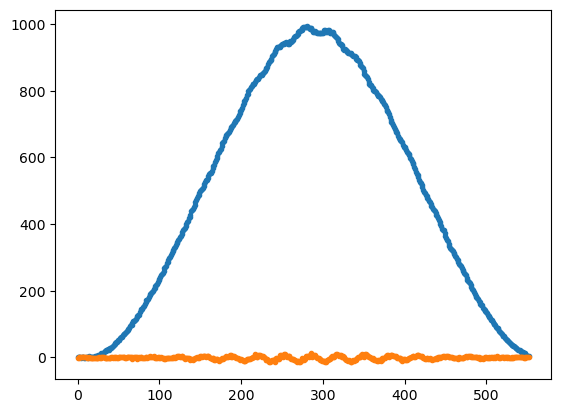

In [13]:
plt.figure()
plt.plot(iq_mat.ticks, np.real(iq_mat.sel(rox=1)), '.-')
plt.plot(iq_mat.ticks, np.imag(iq_mat.sel(rox=1)), '.-')
plt.show()

In [14]:
x=np.max(np.real(iq_mat.sel(rox=1))).compute() + 1j*np.max(np.imag(iq_mat.sel(rox=1))).compute()
ph = x/np.abs(x)
print(ph)

<xarray.DataArray 'IQ decimated' ()> Size: 16B
array(0.99992699+0.01208371j)
Coordinates:
    rox      int32 4B 1
